In [3]:
import numpy as np
import sys
import torch
import matplotlib.pyplot as plt
import os
import xml.etree.ElementTree as ET
import cv2
import albumentations as A
import random

In [ ]:
#Для модели с нуля.
from sklearn.cluster import KMeans
from collections import OrderedDict


Для разметки данных использую labelimg.

In [ ]:
print(sys.executable)
print(sys.version)

/home/svetotch/ML_Itmo/machine_learning_hogweeds/venv/bin/python
3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]


In [2]:
print(torch.cuda.is_available())

True


In [19]:
xml_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/dataset_hogweed/blooming/annotations_blooming"
img_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/dataset_hogweed/blooming/images_blooming"

yolo_labels_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/dataset_hogweed/blooming/labels_blooming"

In [20]:
os.makedirs(yolo_labels_dir, exist_ok=True)

CLASS_MAP = {
    "blooming_sosnovsky": 0,
    "faded_sosnovsky": 1,
    "thickets_sosnovsky":2
}


def convert(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x = (box[0] + box[1]) / 2.0 * dw
    y = (box[2] + box[3]) / 2.0 * dh
    w = (box[1] - box[0]) * dw
    h = (box[3] - box[2]) * dh

    return x, y, w, h


for xml_file in os.listdir(xml_dir):

    if not xml_file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(xml_dir, xml_file))
    root = tree.getroot()

    size = root.find("size")
    w_img = int(size.find("width").text)
    h_img = int(size.find("height").text)

    lines = []

    for obj in root.findall("object"):
        name = obj.find("name").text

        if name not in CLASS_MAP:
            continue

        class_id = CLASS_MAP[name]

        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        xmax = float(bnd.find("xmax").text)
        ymin = float(bnd.find("ymin").text)
        ymax = float(bnd.find("ymax").text)

        x, y, w, h = convert(
                    (w_img, h_img),
                    (xmin, xmax, ymin, ymax)
                    )

        lines.append(f"{class_id} {x} {y} {w} {h}")

    txt_name = xml_file.replace(".xml", ".txt")

    with open(os.path.join(yolo_labels_dir, txt_name), "w") as f:
        f.write("\n".join(lines))

print("yolo labels created")

yolo labels created


In [21]:
images = {os.path.splitext(x)[0] for x in os.listdir(img_dir)}
labels = {os.path.splitext(x)[0] for x in os.listdir(yolo_labels_dir)}

print("images:", len(images))
print("labels:", len(labels))

print("missing labels:", len(images - labels))
print("missing images:", len(labels - images))

images: 2003
labels: 2003
missing labels: 0
missing images: 0


In [24]:
# Модуль для копирования файлов
import shutil

# Корневая директория нового датасета
out = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset"

# Список директорий, которые необходимо создать
# Структура соответствует формату YOLO
dirs = [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
]

# Создание всех необходимых папок
for d in dirs:

    # Формирование полного пути и создание директории
    # exist_ok=True предотвращает ошибку,
    # если папка уже существует
    os.makedirs(os.path.join(out, d), exist_ok=True)

# Получение списка всех изображений
images = os.listdir(img_dir)

# Фиксация генератора случайных чисел
# чтобы разбиение было воспроизводимым
random.seed(42)

# Случайное перемешивание списка изображений
random.shuffle(images)

# Общее количество изображений
n = len(images)

# Граница обучающей выборки (70%)
train_end = int(n * 0.7)

# Граница валидационной выборки (15%)
val_end = int(n * 0.85)

# Формирование обучающей выборки
train = images[:train_end]

# Формирование валидационной выборки
val = images[train_end:val_end]

# Формирование тестовой выборки
test = images[val_end:]

# Вывод размеров полученных подмножеств
print(f"train: {len(train)}")
print(f"val:   {len(val)}")
print(f"test:  {len(test)}")


# Функция копирования изображений и аннотаций
def copy_files(data, split):

    # Перебор всех изображений выбранного поднабора
    for img in data:

        # Получение имени файла без расширения
        # Например:
        # IMG_001.jpg -> IMG_001
        name = os.path.splitext(img)[0]

        # Полный путь к изображению
        img_src = os.path.join(img_dir, img)

        # Полный путь к соответствующей разметке
        lbl_src = os.path.join(yolo_labels_dir, name + ".txt")

        # Путь назначения изображения
        img_dst = os.path.join(out, "images", split, img)

        # Путь назначения разметки
        lbl_dst = os.path.join(out, "labels", split, name + ".txt")

        # Копирование изображения
        shutil.copy(img_src, img_dst)

        # Проверка существования файла разметки
        if os.path.exists(lbl_src):

            # Копирование разметки
            shutil.copy(lbl_src, lbl_dst)

        else:

            # Сообщение о пропущенной аннотации
            print("missing label:", name)


# Копирование обучающей выборки
copy_files(train, "train")

# Копирование валидационной выборки
copy_files(val, "val")

# Копирование тестовой выборки
copy_files(test, "test")

# Сообщение об успешном завершении подготовки датасета
print("Dataset ready")

train: 1402
val:   300
test:  301
Dataset ready


In [25]:
for split in ["train", "val", "test"]:
    imgs = len(os.listdir(os.path.join(out, "images", split)))
    lbls = len(os.listdir(os.path.join(out, "labels", split)))

    print(split, imgs, lbls)

train 1402 1402
val 300 300
test 301 301


In [26]:
lbl_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/dataset_hogweed/blooming/labels_blooming"

files = os.listdir(lbl_dir)

print("Файлов:", len(files))

for f in files[:5]:
    path = os.path.join(lbl_dir, f)
    print(f, ":", repr(open(path).read()))

Файлов: 2003
blooming_0077.txt : '0 0.423828125 0.7672526041666666 0.138671875 0.30533854166666663\n0 0.494140625 0.58984375 0.576171875 0.10416666666666666\n0 0.600830078125 0.5045572916666666 0.16650390625 0.061197916666666664\n0 0.844482421875 0.4501953125 0.31103515625 0.056640625\n0 0.84912109375 0.6087239583333333 0.08984375 0.15885416666666666\n0 0.930908203125 0.6940104166666666 0.10791015625 0.19401041666666666\n0 0.267822265625 0.8756510416666666 0.11279296875 0.22526041666666666'
blooming_1211.txt : '0 0.569980694980695 0.575487012987013 0.8445945945945946 0.8490259740259741'
blooming_1679.txt : '0 0.5003663003663004 0.49853515625 0.9992673992673993 0.99609375'
blooming_0750.txt : '0 0.152099609375 0.5299219427580225 0.30322265625 0.17346053772766695\n0 0.59521484375 0.6465741543798785 0.115234375 0.2367736339982654\n0 0.56689453125 0.50520381613183 0.111328125 0.11882046834345186\n0 0.755859375 0.5290546400693842 0.2314453125 0.16131830008673026\n0 0.966552734375 0.53425845

shutil.rmtree(
    "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset"
)

In [27]:
print(os.path.exists(
    "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset"
))

True


In [2]:
from ultralytics import YOLO

In [3]:
model = YOLO("yolov8n.pt")

model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="/home/svetotch/ML_Itmo/yolo_runs", 
    name="hogweed_exp1"
)

New https://pypi.org/project/ultralytics/8.4.75 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15832MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7788cad84e50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
model = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_exp1/weights/best.pt")

In [13]:
print(len(os.listdir("/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test")))

301


In [14]:
metrics = model.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="val_exp1"
)

print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)
print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7622.7±6778.3 MB/s, size: 1408.4 KB)
val: Scanning /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 3.9Kit/s 0.1s
val: New cache created: /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 13.3it/s 1.4s0.1s
                   all        301        834      0.401      0.386      0.338      0.167
    blooming_sosnovsky        291        665      0.653      0.644      0.697      0.368
       faded_sosnovsky         34         58      0.269      0.172       0.12     0.0486
    thickets_sosnovsky         57        111

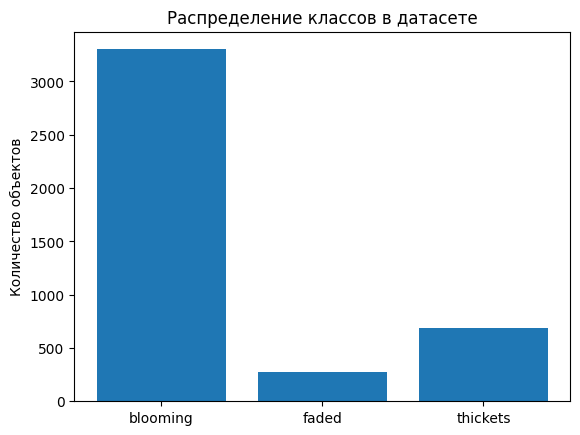

In [ ]:
import matplotlib.pyplot as plt

class_counts = {0: 3302, 1: 275, 2: 685}

names = ["blooming", "faded", "thickets"]
values = list(class_counts.values())

plt.figure()
plt.bar(names, values)
plt.title("Распределение классов в датасете")
plt.ylabel("Количество объектов")
plt.show()

Сейчас сильный дисбаланс так как модель обученна только на части датасета где есть цветущий борщевик

так как датасет пока размечен не до конца, модель йоло пока плохо находит классы 2 и 1

Однако она очень хорошо находит класс blooming.


Первая модель просто обученная YOLOv8 Nano. Результаты метрик:
# Precision = 0.401498988959478
# Recall = 0.38612171933406053
# mAP50 = 0.3383189593039473
# mAP50-95 = 0.16677254396548885

In [ ]:
results = model.predict(
    source="/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test",
    conf=0.23,
    save=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="predict_exp1"
)

Ещё одна модель. На этот раз yolov8small

In [ ]:
model2 = YOLO("yolov8s.pt")

model2.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="/home/svetotch/ML_Itmo/yolo_runs", 
    name="hogweed_exp2"
)

New https://pypi.org/project/ultralytics/8.4.69 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7685b6a202e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
model2 = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_exp2/weights/best.pt")
metrics = model2.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="test_exp2"
)

print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)
print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15818MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14396.5±3183.4 MB/s, size: 1736.9 KB)
val: Scanning /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test.cache... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 90.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 9.9it/s 1.9s<0.1s
                   all        301        834      0.471      0.411      0.397      0.196
    blooming_sosnovsky        291        665      0.707       0.65       0.72      0.387
       faded_sosnovsky         34         58      0.407      0.276      0.204      0.083
    thickets_sosnovsky         57        111      0.299      0.306      0.268      0.118
Speed: 0.6ms preprocess, 2.8ms inference, 0.0ms loss, 0.9

In [ ]:
results = model2.predict(
    source="/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test",
    conf=0.23,
    save=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="predict_exp2"
)


image 1/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0004.jpg: 480x640 1 blooming_sosnovsky, 18.2ms
image 2/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0008.jpg: 640x640 1 blooming_sosnovsky, 3.8ms
image 3/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0010.jpg: 640x480 1 blooming_sosnovsky, 17.4ms
image 4/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0016.jpg: 640x480 1 blooming_sosnovsky, 2.5ms
image 5/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0018.jpg: 480x640 5 blooming_sosnovskys, 3 thickets_sosnovskys, 2.5ms
image 6/301 /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test/blooming_0033.jpg: 640x480 3 blooming_sosnovskys, 2 thickets_sosnovskys, 2.6ms
image 7/301 /home/svetotch/ML_Itmo/machine_learning_hog

# Precision = 0.4707891633767655
# Recall = 0.4105974784740665
# mAP50 = 0.3972891420088777
# mAP50-95 = 0.19620398533894992

Для сравнения были обучены две модели: YOLOv8n и YOLOv8s. 

Вторая модель показала лучшие результаты по всем метрикам качества. 
Наибольший прирост наблюдался по Precision и mAP@0.5, что свидетельствует о более точной локализации объектов и меньшем количестве ложных срабатываний. 
Совокупная метрика качества mAP@0.5:0.95 увеличилась с 0.167 до 0.196, что соответствует приросту около 17%.

In [6]:
train_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/train"
val_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/val"
test_bloom_images = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/images/test"


train_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/train"
val_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/val"
test_bloom_labels = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test"

## Аугментация

In [ ]:
# Сколько копий делать
N_AUG = 3

transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20,
            p=0.5
        ),

        A.Rotate(
            limit=15,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5
        ),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

In [29]:
def read_yolo_label(path):
    boxes = []
    labels = []

    with open(path, "r") as f:
        for line in f:
            cls, x, y, w, h = map(float, line.strip().split())

            labels.append(int(cls))
            boxes.append([x, y, w, h])

    return boxes, labels

In [30]:
def save_yolo_label(path, boxes, labels):
    with open(path, "w") as f:
        for cls, box in zip(labels, boxes):
            x, y, w, h = box
            f.write(f"{cls} {x} {y} {w} {h}\n")

In [31]:
for image_name in os.listdir(train_bloom_images):

    if not image_name.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):
        continue

    image_path = os.path.join(train_bloom_images, image_name)

    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(train_bloom_labels, label_name)

    if not os.path.exists(label_path):
        continue

    boxes, labels = read_yolo_label(label_path)

    # аугментируем только редкие классы
    if not any(cls in [1, 2] for cls in labels):
        continue

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for i in range(N_AUG):

        transformed = transform(
            image=image,
            bboxes=boxes,
            class_labels=labels
        )

        aug_image = transformed["image"]
        aug_boxes = transformed["bboxes"]
        aug_labels = transformed["class_labels"]

        new_image_name = (
            os.path.splitext(image_name)[0]
            + f"_aug_{i}.jpg"
        )

        new_label_name = (
            os.path.splitext(image_name)[0]
            + f"_aug_{i}.txt"
        )

        cv2.imwrite(
            os.path.join(train_bloom_images, new_image_name),
            cv2.cvtColor(
                aug_image,
                cv2.COLOR_RGB2BGR
            )
        )

        save_yolo_label(
            os.path.join(train_bloom_labels, new_label_name),
            aug_boxes,
            aug_labels
        )

print("Аугментация завершена.")

Аугментация завершена.


{0: 7379, 1: 1100, 2: 2740}


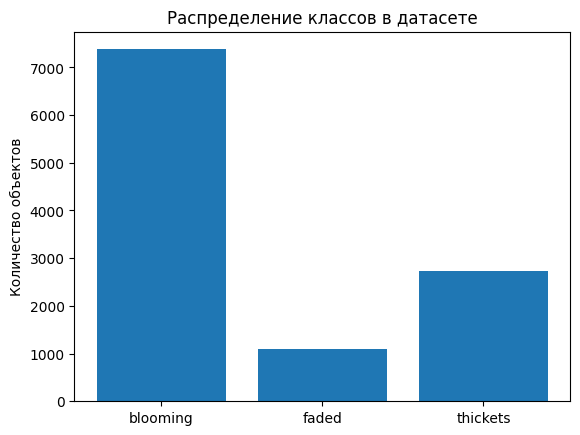

In [6]:
labels_dir = "/home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/train"

class_counts = {}

for file in os.listdir(labels_dir):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(labels_dir, file)

    with open(path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 0:
            continue

        cls_id = int(float(parts[0]))

        class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

print(class_counts)

names = ["blooming", "faded", "thickets"]
values = list(class_counts.values())

plt.figure()
plt.bar(names, values)
plt.title("Распределение классов в датасете")
plt.ylabel("Количество объектов")
plt.show()

Аугментация на данный момент не увеличит точность так как датасет не полностью пока помечен

Модель с аугментацией

In [32]:
model2 = YOLO("yolov8s.pt")

model2.train(
    data="dataset.yaml",
    epochs=80,
    imgsz=960,
    mosaic=1.0,
    mixup=0.2,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    batch=8,
    project="/home/svetotch/ML_Itmo/yolo_runs", 
    name="hogweed_exp3"
)

New https://pypi.org/project/ultralytics/8.4.76 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15832MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7785a4a7a800>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [33]:
model2 = YOLO("/home/svetotch/ML_Itmo/yolo_runs/hogweed_exp3-3/weights/best.pt")
metrics = model2.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    project="/home/svetotch/ML_Itmo/yolo_runs",
    name="test_exp3-3"
)

print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)
print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15832MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1419.9±360.2 MB/s, size: 1736.9 KB)
val: Scanning /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 3.9Kit/s 0.1s
val: New cache created: /home/svetotch/ML_Itmo/machine_learning_hogweeds/hogweed/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 6.1it/s 3.1s<0.2s
                   all        301        834      0.447      0.376      0.328       0.14
    blooming_sosnovsky        291        665      0.638      0.626      0.624      0.274
       faded_sosnovsky         34         58      0.389      0.259      0.169     0.0713
    thickets_sosnovsky         57        11

Модель с аугментированным датасетом показала результат хуже.

## Precision = 0.44745841750851617 
## Recall = 0.37580928089095056 
## mAP50 = 0.3276943831072961 
## mAP50-95 = 0.1403370683995934

Посравнению с предыдущей 

# Precision = 0.4707891633767655
# Recall = 0.4105974784740665
# mAP50 = 0.3972891420088777
# mAP50-95 = 0.19620398533894992

Делаю вывод что аугментация на данный момент не даёт результат. Так как yolo уже сама по себе хорошо обучена(скорее нет, чем да). Аугментация скорее больше шум на данный момент.

Всего боксов: 4262


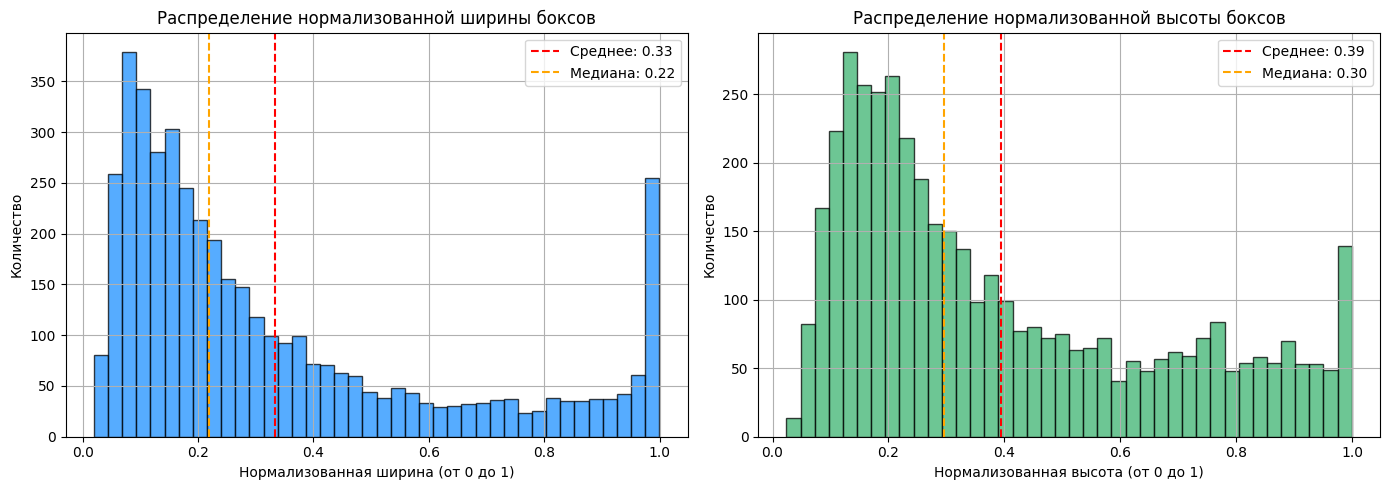

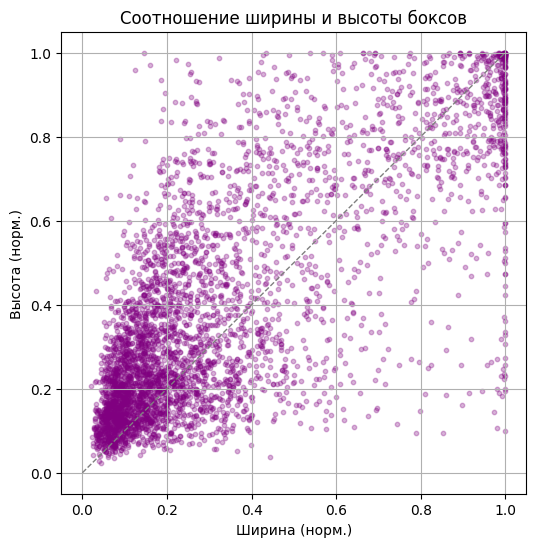

In [ ]:
# списки для хранения ширины и высоты всех bounding boxes
widths = []
heights = []

# проходим по всем файлам разметки в train-части датасета
for filename in os.listdir(train_bloom_labels):
    if not filename.endswith(".txt"):
        continue
    # полный путь к файлу разметки
    path = os.path.join(train_bloom_labels, filename)
     # открываем файл
    with open(path, "r") as f:
        lines = f.readlines()
    # каждая строка = один объект (bounding box)
    for line in lines:
        # YOLO формат:
        # class x_center y_center width height
        cls, x_center, y_center, w, h = map(float, line.split())
        # сохраняем только размеры бокса (нас не интересует позиция)
        widths.append(w)
        heights.append(h)

print(f"Всего боксов в train: {len(widths)}")

# Преобразование в numpy для статистики
widths = np.array(widths)
heights = np.array(heights)

# Гистограммы 
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=40, color='dodgerblue', alpha=0.75, edgecolor='black')
plt.axvline(np.mean(widths), color='red', linestyle='--', label=f"Среднее: {np.mean(widths):.2f}")
plt.axvline(np.median(widths), color='orange', linestyle='--', label=f"Медиана: {np.median(widths):.2f}")
plt.title("Распределение нормализованной ширины боксов")
plt.xlabel("Нормализованная ширина (от 0 до 1)")
plt.ylabel("Количество")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(heights, bins=40, color='mediumseagreen', alpha=0.75, edgecolor='black')
plt.axvline(np.mean(heights), color='red', linestyle='--', label=f"Среднее: {np.mean(heights):.2f}")
plt.axvline(np.median(heights), color='orange', linestyle='--', label=f"Медиана: {np.median(heights):.2f}")
plt.title("Распределение нормализованной высоты боксов")
plt.xlabel("Нормализованная высота (от 0 до 1)")
plt.ylabel("Количество")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Точечный график 
plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.3, s=10, color='purple')
plt.title("Соотношение ширины и высоты боксов")
plt.xlabel("Ширина (норм.)")
plt.ylabel("Высота (норм.)")
plt.grid(True)

# Добавим линию x = y для ориентира
max_val = max(np.max(widths), np.max(heights))
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', linewidth=1)

plt.show()

То, что среднее больше медианы, говорит о правосторонней асимметрии распределения. Иными словами:

большинство объектов имеют небольшие или средние размеры;
присутствует заметное количество очень крупных объектов, которые смещают среднее значение вправо.

Это типичная ситуация для задач детекции растений:

часть изображений содержит отдельные растения крупным планом;
часть — группы растений или растения на большом расстоянии.


На обеих гистограммах хорошо заметен пик около значения 1.0.

Это означает, что в датасете присутствует значительное число боксов, занимающих практически всё изображение.

Это повышает разнообразие масштабов объектов и способствует более устойчивому обучению модели? 

Из графиков видно, что ширина и высота объектов изменяются практически по всему диапазону

Это очень хороший признак для YOLO.




Положительная корреляция:

Чем шире объект, тем выше он становится.

Точки образуют диагональное облако.

Это говорит о том, что большинство объектов сохраняют примерно одинаковые пропорции.

Анализ 4262 размеченных объектов показал высокую вариативность размеров bounding boxes. Большинство объектов имеют небольшие и средние размеры, однако в выборке также присутствует значительное количество крупных объектов, занимающих большую часть изображения. Наблюдается положительная корреляция между шириной и высотой объектов, что свидетельствует о согласованности разметки и отсутствии значительного числа аномальных ограничивающих прямоугольников.

Пробую добавить backbone